# Bloque 3 — NLP y modelo pre-entrenado

**Corpus:** Reseñas de aplicaciones financieras colombianas (Nequi, Bancolombia, Daviplata, Rappi) obtenidas de Google Play Store.

**Objetivo:** Comparar un pipeline clásico de NLP (TF-IDF + Regresión Logística) con un modelo pre-entrenado de Hugging Face (robertuito) para clasificación de sentimiento, analizando las fortalezas y limitaciones de cada enfoque en este contexto específico.

In [1]:
# ============================================================
# Scraping de reseñas — Google Play Store
# ============================================================
import pandas as pd
import os
import time

ARCHIVO_RESENAS = "../datos/resenas_apps.csv"

if not os.path.exists(ARCHIVO_RESENAS):
    from google_play_scraper import Sort, reviews

    # Apps financieras colombianas
    apps = {
        "Nequi": "com.nequi.MobileApp",
        "Bancolombia": "com.todo1.mobile",
        "Daviplata": "com.davivienda.daviplata",
        "Rappi": "com.grability.rappi"
    }

    todas_resenas = []

    for nombre, app_id in apps.items():
        print(f"Descargando reseñas de {nombre}...")
        try:
            resultado, _ = reviews(
                app_id,
                lang="es",
                country="co",
                sort=Sort.NEWEST,
                count=800,
                filter_score_with=None
            )
            for r in resultado:
                todas_resenas.append({
                    "app": nombre,
                    "texto": r["content"],
                    "estrellas": r["score"],
                    "fecha": r["at"].strftime("%Y-%m-%d") if r["at"] else None,
                    "likes": r.get("thumbsUpCount", 0)
                })
            print(f"  {len(resultado)} reseñas obtenidas")
        except Exception as e:
            print(f"  Error con {nombre}: {e}")

    df_resenas = pd.DataFrame(todas_resenas)
    os.makedirs("../datos", exist_ok=True)
    df_resenas.to_csv(ARCHIVO_RESENAS, index=False)
    print(f"\nTotal: {len(df_resenas):,} reseñas guardadas en {ARCHIVO_RESENAS}")
else:
    df_resenas = pd.read_csv(ARCHIVO_RESENAS)
    print(f"Archivo existente: {len(df_resenas):,} reseñas cargadas")
if "Daviplata" not in df_resenas["app"].unique():
    print("\nNota: Daviplata (com.davivienda.daviplata) no devolvió reseñas.")
    print("Se continúa con las 3 apps restantes (2,400 reseñas > mínimo de 200).")
# Resumen
print(f"\n--- Resumen del scraping ---")
print(df_resenas["app"].value_counts())
print(f"\nDistribucion de estrellas:")
print(df_resenas["estrellas"].value_counts().sort_index())

Archivo existente: 2,400 reseñas cargadas

Nota: Daviplata (com.davivienda.daviplata) no devolvió reseñas.
Se continúa con las 3 apps restantes (2,400 reseñas > mínimo de 200).

--- Resumen del scraping ---
app
Nequi          800
Bancolombia    800
Rappi          800
Name: count, dtype: int64

Distribucion de estrellas:
estrellas
1     817
2      72
3      72
4     137
5    1302
Name: count, dtype: int64


In [2]:
# ============================================================
# Limpieza y construccion de etiquetas
# ============================================================
# 1. Eliminar resenas sin texto o muy cortas
df_resenas = df_resenas.dropna(subset=["texto"])
df_resenas = df_resenas[df_resenas["texto"].str.strip().str.len() > 0]

# Largo del texto
df_resenas["largo_texto"] = df_resenas["texto"].str.split().str.len()
print(f"Resenas con texto: {len(df_resenas):,}")
print(f"Palabras por resena: min={df_resenas['largo_texto'].min()}, "
      f"mediana={df_resenas['largo_texto'].median():.0f}, "
      f"max={df_resenas['largo_texto'].max()}")

# 2. Definir sentimiento binario (excluir 3 estrellas)
df_sentimiento = df_resenas[df_resenas["estrellas"] != 3].copy()
df_sentimiento["sentimiento"] = (df_sentimiento["estrellas"] >= 4).astype(int)

print(f"\nResenas despues de excluir 3 estrellas: {len(df_sentimiento):,}")
print(f"\nDistribucion de sentimiento:")
print(df_sentimiento["sentimiento"].value_counts().rename({0: "Negativo (0)", 1: "Positivo (1)"}))

pct_pos = df_sentimiento["sentimiento"].mean() * 100
print(f"\nBalance: {pct_pos:.1f}% positivo / {100-pct_pos:.1f}% negativo")

# 3. Guardar corpus limpio
df_sentimiento.to_csv("../datos/corpus_sentimiento.csv", index=False)
print(f"\nCorpus guardado: ../datos/corpus_sentimiento.csv")

Resenas con texto: 2,400
Palabras por resena: min=1, mediana=5, max=105

Resenas despues de excluir 3 estrellas: 2,328

Distribucion de sentimiento:
sentimiento
Positivo (1)    1439
Negativo (0)     889
Name: count, dtype: int64

Balance: 61.8% positivo / 38.2% negativo

Corpus guardado: ../datos/corpus_sentimiento.csv


In [3]:
# ============================================================
# Iniciar SparkSession y cargar corpus
# ============================================================
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Bloque3_NLP")
    .config("spark.driver.memory", "2g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.csv(
    "../datos/corpus_sentimiento.csv",
    header=True, inferSchema=True, multiLine=True
)

print(f"Corpus cargado: {df.count():,} documentos")
df.printSchema()
df.show(5, truncate=60)

Corpus cargado: 2,328 documentos
root
 |-- app: string (nullable = true)
 |-- texto: string (nullable = true)
 |-- estrellas: string (nullable = true)
 |-- fecha: string (nullable = true)
 |-- likes: string (nullable = true)
 |-- largo_texto: string (nullable = true)
 |-- sentimiento: string (nullable = true)

+-----+------------------------------------------------------------+---------+----------+-----+-----------+-----------+
|  app|                                                       texto|estrellas|     fecha|likes|largo_texto|sentimiento|
+-----+------------------------------------------------------------+---------+----------+-----+-----------+-----------+
|Nequi|esa aplicación no sirve para nada. no sirve con PPT malís...|        1|2026-05-22|    0|         20|          0|
|Nequi|                                                   muy buena|        5|2026-05-22|    0|          2|          1|
|Nequi|                                                   excelente|        5|2026-05-22

---
## Parte A — Preparación del corpus

Se aplica tokenización con `RegexTokenizer` y filtrado de stop words en español. Se reportan estadísticas descriptivas del corpus: total de tokens, vocabulario, TTR (Type-Token Ratio) y hapax legomena.

**Nota sobre el corpus:** La mediana de longitud por reseña es de 5 palabras, lo cual es típico de reseñas de app stores. Esto representa una limitación para los métodos basados en frecuencia de términos (TF-IDF), ya que cada documento aporta poco contexto léxico.

In [4]:
# ============================================================
# Tokenizacion + Stop Words (con soporte para tildes y ñ)
# ============================================================
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover
from pyspark.sql.functions import (
    col, size, explode, countDistinct, count, lower, trim,
    sum as spark_sum, desc
)

# 1. Limpiar texto: minusculas y espacios
df = df.withColumn("texto_limpio", trim(lower(col("texto"))))

# 2. RegexTokenizer — patron corregido para español
# \W+ corta en tildes. Usamos [^a-záéíóúüñ]+ para respetar acentos
tokenizer = RegexTokenizer(
    inputCol="texto_limpio",
    outputCol="tokens_raw",
    pattern=r"[^a-záéíóúüñ]+",
    minTokenLength=2
)
df = tokenizer.transform(df)

# 3. Stop words en español
stop_words_es = StopWordsRemover.loadDefaultStopWords("spanish")
stop_extra = [
    "app", "aplicación", "aplicacion", "si", "no", "ya", "mas", "más",
    "muy", "solo", "hace", "puede", "ser", "va", "hay",
    "esa", "ese", "eso", "esta", "esto", "aquí", "ahí",
    "está", "así", "también", "porque", "para", "como",
    "todo", "bien", "uno", "tan"
]
stop_words_total = list(set(stop_words_es + stop_extra))

remover = StopWordsRemover(
    inputCol="tokens_raw",
    outputCol="tokens",
    stopWords=stop_words_total
)
df = remover.transform(df)

df = df.withColumn("n_tokens_raw", size("tokens_raw"))
df = df.withColumn("n_tokens", size("tokens"))

print("Tokenización completada (con soporte para tildes).\n")
print("Ejemplo de tokenización:")
df.select("texto_limpio", "tokens_raw", "tokens").show(3, truncate=50)

Tokenización completada (con soporte para tildes).

Ejemplo de tokenización:
+--------------------------------------------------+--------------------------------------------------+------------------------------------------+
|                                      texto_limpio|                                        tokens_raw|                                    tokens|
+--------------------------------------------------+--------------------------------------------------+------------------------------------------+
|esa aplicación no sirve para nada. no sirve con...|[esa, aplicación, no, sirve, para, nada, no, si...|[sirve, sirve, ppt, malísima, peso, culpa]|
|                                         muy buena|                                      [muy, buena]|                                   [buena]|
|                                         excelente|                                       [excelente]|                               [excelente]|
+----------------------------------------

In [5]:
# ============================================================
# Estadisticas descriptivas del corpus
# ============================================================

total_docs = df.count()

# Total de tokens (despues de stop words)
total_tokens = df.select(spark_sum("n_tokens")).collect()[0][0]

# Vocabulario: tokens unicos
df_tokens = df.select(explode("tokens").alias("token"))
vocabulario = df_tokens.distinct().count()

# TTR (Type-Token Ratio)
ttr = vocabulario / total_tokens

print("=== Estadisticas descriptivas del corpus ===\n")
print(f"Total de documentos (resenas):  {total_docs:,}")
print(f"Total de tokens:                {total_tokens:,}")
print(f"Vocabulario (types):            {vocabulario:,}")
print(f"TTR (Type-Token Ratio):         {ttr:.4f}")
print(f"Tokens promedio por documento:  {total_tokens / total_docs:.1f}")

# Distribucion de tokens por documento
print(f"\n--- Tokens por documento (despues de stop words) ---")
df.select("n_tokens").describe().show()

=== Estadisticas descriptivas del corpus ===

Total de documentos (resenas):  2,328
Total de tokens:                16,015
Vocabulario (types):            3,811
TTR (Type-Token Ratio):         0.2380
Tokens promedio por documento:  6.9

--- Tokens por documento (despues de stop words) ---
+-------+-----------------+
|summary|         n_tokens|
+-------+-----------------+
|  count|             2328|
|   mean|6.879295532646048|
| stddev|9.429973562760344|
|    min|                0|
|    max|               48|
+-------+-----------------+



In [6]:
# ============================================================
# Hapax Legomena — palabras que aparecen exactamente una vez
# ============================================================

# Contar frecuencia de cada token en todo el corpus
freq_tokens = df_tokens.groupBy("token").agg(count("*").alias("freq"))

# Hapax: freq == 1
hapax = freq_tokens.filter(col("freq") == 1)
n_hapax = hapax.count()
pct_hapax = n_hapax / vocabulario * 100

print(f"=== Hapax Legomena ===\n")
print(f"Hapax legomena:          {n_hapax:,}")
print(f"Porcentaje del vocab:    {pct_hapax:.1f}%")
print(f"Vocabulario total:       {vocabulario:,}")

print(f"\nEjemplos de hapax legomena:")
hapax.orderBy("token").show(10, truncate=False)

# Top 20 palabras mas frecuentes (para contraste)
print("Top 20 palabras mas frecuentes:")
freq_tokens.orderBy(desc("freq")).show(20, truncate=False)

=== Hapax Legomena ===

Hapax legomena:          2,163
Porcentaje del vocab:    56.8%
Vocabulario total:       3,811

Ejemplos de hapax legomena:
+------------+----+
|token       |freq|
+------------+----+
|aaaa        |1   |
|aaaaaaaa    |1   |
|abra        |1   |
|abran       |1   |
|abreeeeee   |1   |
|abro        |1   |
|abruptamente|1   |
|abrí        |1   |
|abusadores  |1   |
|abuso       |1   |
+------------+----+
only showing top 10 rows

Top 20 palabras mas frecuentes:
+----------+----+
|token     |freq|
+----------+----+
|excelente |327 |
|buena     |306 |
|pedido    |288 |
|servicio  |196 |
|rappi     |112 |
|deja      |109 |
|nunca     |101 |
|exelente  |99  |
|dinero    |99  |
|hora      |93  |
|pedidos   |92  |
|soporte   |92  |
|hacer     |90  |
|bueno     |89  |
|mejor     |84  |
|cuenta    |81  |
|repartidor|79  |
|ahora     |77  |
|nequi     |77  |
|siempre   |73  |
+----------+----+
only showing top 20 rows



### Reflexión sobre hapax legomena

Los hapax legomena (2,163 palabras, el 56.8% del vocabulario) representan más de la mitad de los types del corpus. Este porcentaje alto es esperado en un corpus de reseñas cortas (mediana de 5 palabras por documento) porque:

1. Cada documento aporta pocas palabras, reduciendo la probabilidad de repetición entre documentos.
2. Los usuarios emplean vocabulario informal con variantes ortográficas (por ejemplo, "exelente" aparece 99 veces como variante de "excelente") y regionalismos que generan tokens únicos.
3. Errores de ortografía y expresiones enfáticas como "abreeeeee" o "aaaaaaaa" crean tokens artificiales irrepetibles.

**Decisión:** No se filtran los hapax del corpus. Eliminarlos reduciría el vocabulario sin mejorar la clasificación, ya que `CountVectorizer` con `minDF=3` se encarga de ignorarlos implícitamente al requerir que cada término aparezca en al menos 3 documentos.

---
## Parte B — TF-IDF y análisis estadístico

Se aplica `CountVectorizer` + `IDF` para obtener representaciones TF-IDF del corpus. Se comparan las palabras más relevantes según frecuencia bruta (TF) y según TF-IDF para identificar cómo la ponderación inversa por documento modifica la importancia relativa de los términos.

In [7]:
# ============================================================
# Pipeline TF-IDF: CountVectorizer + IDF
# ============================================================
from pyspark.ml.feature import CountVectorizer, IDF

# CountVectorizer (TF crudo)
cv = CountVectorizer(
    inputCol="tokens",
    outputCol="tf_raw",
    minDF=3,         # ignorar palabras que aparecen en menos de 3 docs
    vocabSize=5000   # maximo de vocabulario
)
cv_model = cv.fit(df)
df = cv_model.transform(df)

# IDF sobre el TF
idf = IDF(inputCol="tf_raw", outputCol="tfidf")
idf_model = idf.fit(df)
df = idf_model.transform(df)

vocabulario_cv = cv_model.vocabulary
print(f"Vocabulario del CountVectorizer: {len(vocabulario_cv)} terminos")
print(f"(de {3811} types originales, se conservaron los que aparecen en >=3 docs)\n")

print("Primeros 20 terminos del vocabulario (ordenados por frecuencia):")
for i, palabra in enumerate(vocabulario_cv[:20]):
    print(f"  {i:>3}. {palabra}")

Vocabulario del CountVectorizer: 1056 terminos
(de 3811 types originales, se conservaron los que aparecen en >=3 docs)

Primeros 20 terminos del vocabulario (ordenados por frecuencia):
    0. excelente
    1. buena
    2. pedido
    3. servicio
    4. rappi
    5. deja
    6. nunca
    7. exelente
    8. dinero
    9. hora
   10. soporte
   11. pedidos
   12. hacer
   13. bueno
   14. mejor
   15. cuenta
   16. repartidor
   17. nequi
   18. ahora
   19. siempre


In [8]:
# ============================================================
# Comparacion: Top palabras por TF crudo vs TF-IDF
# ============================================================
import numpy as np

# Obtener vectores IDF (peso de cada termino)
idf_values = idf_model.idf.toArray()

# Top 15 por TF (frecuencia bruta global)
tf_global = np.zeros(len(vocabulario_cv))
for row in df.select("tf_raw").collect():
    tf_global += row[0].toArray()

top_tf = np.argsort(tf_global)[::-1][:15]

# Top 15 por TF-IDF promedio
tfidf_promedio = np.zeros(len(vocabulario_cv))
for row in df.select("tfidf").collect():
    tfidf_promedio += row[0].toArray()
tfidf_promedio /= df.count()

top_tfidf = np.argsort(tfidf_promedio)[::-1][:15]

# Tabla comparativa
print("=== Top 15: TF crudo vs TF-IDF promedio ===\n")
print(f"{'Rank':<5} {'TF crudo':<20} {'TF':>8}  |  {'TF-IDF':<20} {'Score':>8}")
print("-" * 70)
for i in range(15):
    tf_word = vocabulario_cv[top_tf[i]]
    tf_val = tf_global[top_tf[i]]
    tfidf_word = vocabulario_cv[top_tfidf[i]]
    tfidf_val = tfidf_promedio[top_tfidf[i]]
    print(f"{i+1:<5} {tf_word:<20} {tf_val:>8.0f}  |  {tfidf_word:<20} {tfidf_val:>8.4f}")

=== Top 15: TF crudo vs TF-IDF promedio ===

Rank  TF crudo                   TF  |  TF-IDF                  Score
----------------------------------------------------------------------
1     excelente                 327  |  pedido                 0.3031
2     buena                     306  |  excelente              0.2762
3     pedido                    288  |  buena                  0.2676
4     servicio                  196  |  servicio               0.2156
5     rappi                     112  |  rappi                  0.1555
6     deja                      109  |  deja                   0.1474
7     nunca                     101  |  dinero                 0.1408
8     exelente                   99  |  nunca                  0.1397
9     dinero                     99  |  hora                   0.1367
10    hora                       93  |  exelente               0.1339
11    soporte                    92  |  pedidos                0.1337
12    pedidos                    92  |  sopo

In [9]:
# ============================================================
# Top palabras TF-IDF por clase de sentimiento
# ============================================================

for clase, nombre in [(1, "POSITIVO"), (0, "NEGATIVO")]:
    tfidf_clase = np.zeros(len(vocabulario_cv))
    n_clase = 0
    
    for row in df.filter(col("sentimiento") == clase).select("tfidf").collect():
        tfidf_clase += row[0].toArray()
        n_clase += 1
    
    tfidf_clase /= n_clase
    top_idx = np.argsort(tfidf_clase)[::-1][:15]
    
    print(f"\n=== Top 15 TF-IDF — Sentimiento {nombre} (n={n_clase}) ===\n")
    for i, idx in enumerate(top_idx):
        print(f"  {i+1:>2}. {vocabulario_cv[idx]:<20} {tfidf_clase[idx]:.4f}")


=== Top 15 TF-IDF — Sentimiento POSITIVO (n=1443) ===

   1. excelente            0.4415
   2. buena                0.4064
   3. exelente             0.2160
   4. bueno                0.1916
   5. gracias              0.1518
   6. mejor                0.1441
   7. super                0.1139
   8. fácil                0.1121
   9. servicio             0.0940
  10. nequi                0.0902
  11. buen                 0.0762
  12. bancolombia          0.0749
  13. genial               0.0698
  14. gusta                0.0694
  15. nueva                0.0685

=== Top 15 TF-IDF — Sentimiento NEGATIVO (n=873) ===

   1. pedido               0.7886
   2. servicio             0.4135
   3. rappi                0.3776
   4. deja                 0.3498
   5. nunca                0.3394
   6. hora                 0.3371
   7. soporte              0.3273
   8. pedidos              0.3217
   9. repartidor           0.3200
  10. horas                0.2845
  11. pésimo               0.2817
  12.

### Interpretación TF crudo vs TF-IDF

La comparación muestra que el ranking general es similar pero con reordenamientos relevantes: "pedido" sube de la posición 3 en TF crudo a la 1 en TF-IDF, lo que indica que es un término frecuente pero concentrado en documentos específicos (quejas de delivery), mientras que "excelente" baja de la 1 a la 2 porque, al ser tan omnipresente, su peso IDF es menor.

El análisis por clase de sentimiento revela vocabulario claramente diferenciado:
- **Positivas:** dominadas por adjetivos de satisfacción ("excelente", "buena", "fácil", "genial", "super") y expresiones de gratitud ("gracias"). La presencia de "exelente" (error ortográfico frecuente) confirma la naturaleza informal del corpus.
- **Negativas:** dominadas por vocabulario de quejas de servicio ("pedido", "soporte", "repartidor", "hora", "horas"), marcadores de insatisfacción extrema ("pésimo", "peor", "nunca") y referencias a problemas con dinero ("dinero", "cuenta"). El TF-IDF de "pedido" en negativos (0.79) es casi el doble del mayor score positivo ("excelente", 0.44), reflejando que las quejas tienden a ser más detalladas que los elogios.

---
## Parte C — Clasificación con TF-IDF

Se entrena una Regresión Logística sobre los vectores TF-IDF para clasificar el sentimiento de las reseñas. Se evalúa con accuracy, F1 y matriz de confusión, y se extraen los coeficientes del modelo para identificar las palabras más predictivas de cada clase.

In [10]:
# ============================================================
# Clasificacion: TF-IDF + Logistic Regression
# ============================================================
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)

# Convertir sentimiento a numerico y filtrar labels validos
df = df.withColumn("label", col("sentimiento").cast("double"))
df = df.filter((col("label") == 0.0) | (col("label") == 1.0))
print(f"Documentos con label valido: {df.count():,}")

# Split 80/20
train_nlp, test_nlp = df.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train_nlp.count():,} docs")
print(f"Test:  {test_nlp.count():,} docs")
print(f"\nDistribucion en test:")
test_nlp.groupBy("label").count().show()

# Regresion Logistica sobre TF-IDF
lr_nlp = LogisticRegression(
    featuresCol="tfidf",
    labelCol="label",
    maxIter=100,
    regParam=0.01
)
modelo_lr_nlp = lr_nlp.fit(train_nlp)
pred_lr_nlp = modelo_lr_nlp.transform(test_nlp)

# Metricas
eval_acc = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
)
eval_f1 = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
)
eval_auc = BinaryClassificationEvaluator(
    labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)

accuracy = eval_acc.evaluate(pred_lr_nlp)
f1 = eval_f1.evaluate(pred_lr_nlp)
auc = eval_auc.evaluate(pred_lr_nlp)

print(f"\n=== Regresion Logistica sobre TF-IDF ===")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  F1-Score: {f1:.4f}")
print(f"  AUC:      {auc:.4f}")

Documentos con label valido: 2,316
Train: 1,910 docs
Test:  406 docs

Distribucion en test:
+-----+-----+
|label|count|
+-----+-----+
|  0.0|  155|
|  1.0|  251|
+-----+-----+


=== Regresion Logistica sobre TF-IDF ===
  Accuracy: 0.9039
  F1-Score: 0.9027
  AUC:      0.9574


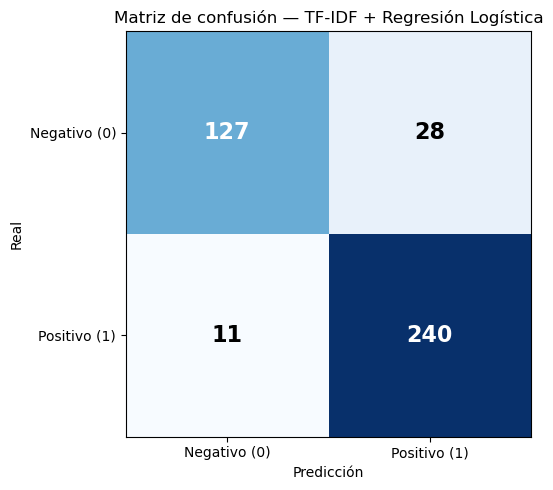


Reporte por clase:
              precision    recall  f1-score   support

    Negativo       0.92      0.82      0.87       155
    Positivo       0.90      0.96      0.92       251

    accuracy                           0.90       406
   macro avg       0.91      0.89      0.90       406
weighted avg       0.90      0.90      0.90       406



In [11]:
# ============================================================
# Matriz de confusion — TF-IDF + LogReg
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

pdf_pred = pred_lr_nlp.select("label", "prediction").toPandas()
cm = confusion_matrix(pdf_pred["label"], pdf_pred["prediction"])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Negativo (0)", "Positivo (1)"])
ax.set_yticklabels(["Negativo (0)", "Positivo (1)"])
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — TF-IDF + Regresión Logística")

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                color=color, fontsize=16, fontweight="bold")

plt.tight_layout()
plt.savefig("../bloque3_nlp/fig1_confusion_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nReporte por clase:")
print(classification_report(
    pdf_pred["label"], pdf_pred["prediction"],
    target_names=["Negativo", "Positivo"]
))

In [12]:
# ============================================================
# Coeficientes: palabras mas predictivas por clase
# ============================================================
import numpy as np

coeficientes = modelo_lr_nlp.coefficients.toArray()
vocabulario_cv = cv_model.vocabulary

# Top palabras para clase positiva (coeficientes mas positivos)
top_pos = np.argsort(coeficientes)[::-1][:15]
# Top palabras para clase negativa (coeficientes mas negativos)
top_neg = np.argsort(coeficientes)[:15]

print("=== Palabras mas predictivas por clase ===\n")
print(f"{'POSITIVO':<30} {'NEGATIVO':<30}")
print(f"{'Palabra':<20} {'Coef':>8}    {'Palabra':<20} {'Coef':>8}")
print("-" * 62)
for i in range(15):
    p_word = vocabulario_cv[top_pos[i]]
    p_coef = coeficientes[top_pos[i]]
    n_word = vocabulario_cv[top_neg[i]]
    n_coef = coeficientes[top_neg[i]]
    print(f"{p_word:<20} {p_coef:>+8.4f}    {n_word:<20} {n_coef:>+8.4f}")

=== Palabras mas predictivas por clase ===

POSITIVO                       NEGATIVO                      
Palabra                  Coef    Palabra                  Coef
--------------------------------------------------------------
excelente             +1.0481    todavía               -0.7945
buena                 +0.8691    porquería             -0.7841
exelente              +0.7002    mala                  -0.7834
vamos                 +0.6992    público               -0.6842
interesante           +0.6706    estafadores           -0.6730
presenta              +0.6662    pésimo                -0.6616
momentos              +0.6637    horrible              -0.6349
bueno                 +0.6135    clara                 -0.6124
favor                 +0.6121    estafan               -0.6085
seguir                +0.5962    peor                  -0.6062
increíble             +0.5892    pesima                -0.6044
cola                  +0.5700    pesimo                -0.6025
buen        

---
## Parte D — Modelo pre-entrenado de Hugging Face

Se aplica `pysentimiento/robertuito-sentiment-analysis` al corpus completo. Este modelo fue pre-entrenado sobre tweets en español y clasifica texto en tres categorías (POS, NEG, NEU). Se mapea su salida a clasificación binaria para comparar con el modelo TF-IDF entrenado en la Parte C.

In [13]:
# ============================================================
# Modelo pre-entrenado: robertuito-sentiment-analysis
# ============================================================
from transformers import pipeline
import pandas as pd
import numpy as np

print("Cargando modelo robertuito...")
clasificador_hf = pipeline(
    "sentiment-analysis",
    model="pysentimiento/robertuito-sentiment-analysis",
    truncation=True,
    max_length=128
)
print("Modelo cargado.\n")

# Obtener textos y labels reales a Pandas
df_pandas = df.select("texto", "label", "app").toPandas()

# Aplicar robertuito en lotes
print(f"Clasificando {len(df_pandas):,} textos con robertuito...")
textos = df_pandas["texto"].tolist()

# Procesar en lotes de 32
batch_size = 32
predicciones_hf = []
for i in range(0, len(textos), batch_size):
    batch = textos[i:i + batch_size]
    resultados = clasificador_hf(batch)
    predicciones_hf.extend(resultados)
    if (i // batch_size) % 20 == 0:
        print(f"  Procesados: {min(i + batch_size, len(textos)):,}/{len(textos):,}")

print(f"  Procesados: {len(textos):,}/{len(textos):,}")

# Extraer labels y scores
df_pandas["hf_label"] = [p["label"] for p in predicciones_hf]
df_pandas["hf_score"] = [p["score"] for p in predicciones_hf]

# Mapear a binario: POS -> 1, NEG -> 0, NEU -> basado en score
df_pandas["hf_pred"] = df_pandas["hf_label"].map({"POS": 1, "NEG": 0, "NEU": -1})

# Para los NEU, asignar segun el score (si >0.5 positivo)
# Pero primero ver cuantos hay
print(f"\nDistribucion de robertuito:")
print(df_pandas["hf_label"].value_counts())

n_neu = (df_pandas["hf_pred"] == -1).sum()
print(f"\nCasos NEU: {n_neu} ({n_neu/len(df_pandas)*100:.1f}%)")
print("Los NEU se excluyen de la evaluacion binaria.")

# Filtrar solo POS y NEG para evaluacion justa
df_eval = df_pandas[df_pandas["hf_pred"] != -1].copy()
print(f"Documentos evaluables: {len(df_eval):,}")

Cargando modelo robertuito...


Device set to use cpu


Modelo cargado.

Clasificando 2,316 textos con robertuito...
  Procesados: 32/2,316
  Procesados: 672/2,316
  Procesados: 1,312/2,316
  Procesados: 1,952/2,316
  Procesados: 2,316/2,316

Distribucion de robertuito:
hf_label
NEG    906
NEU    740
POS    670
Name: count, dtype: int64

Casos NEU: 740 (32.0%)
Los NEU se excluyen de la evaluacion binaria.
Documentos evaluables: 1,576


=== Comparacion de modelos ===

Modelo                           Accuracy         F1           Datos
--------------------------------------------------------------------
TF-IDF + LogReg (PySpark)      0.9039     0.9027      Test (406)
robertuito (Hugging Face)          0.9302     0.9298   Corpus (1576)

=== Reporte por clase — robertuito ===

              precision    recall  f1-score   support

    Negativo       0.89      0.99      0.94       810
    Positivo       0.99      0.87      0.92       766

    accuracy                           0.93      1576
   macro avg       0.94      0.93      0.93      1576
weighted avg       0.94      0.93      0.93      1576



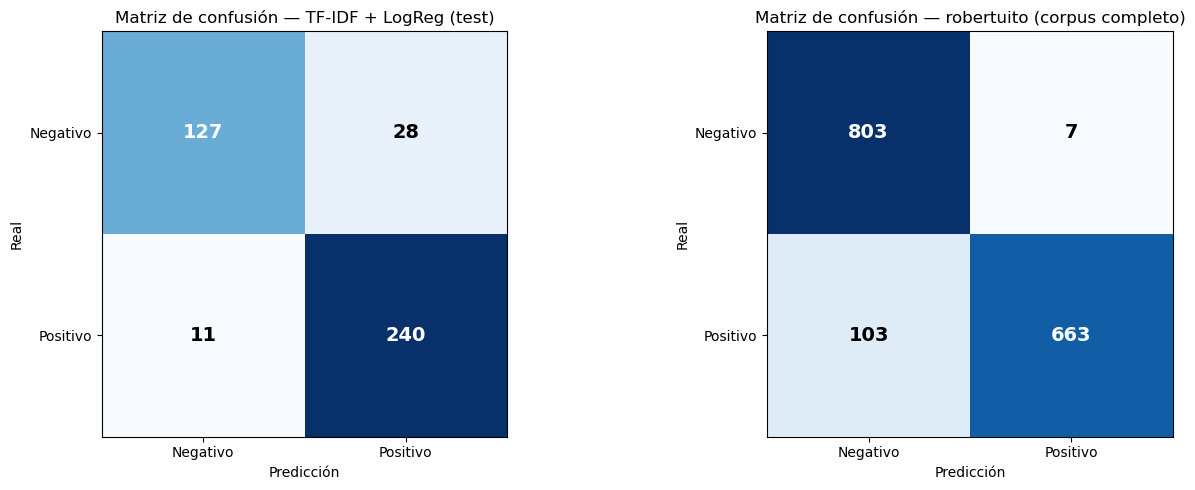

In [14]:
# ============================================================
# Comparacion: TF-IDF vs robertuito
# ============================================================
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Metricas de robertuito (sobre todo el corpus evaluable)
acc_hf = accuracy_score(df_eval["label"], df_eval["hf_pred"])
f1_hf = f1_score(df_eval["label"], df_eval["hf_pred"], average="weighted")

print("=== Comparacion de modelos ===\n")
print(f"{'Modelo':<30} {'Accuracy':>10} {'F1':>10} {'Datos':>15}")
print("-" * 68)
print(f"{'TF-IDF + LogReg (PySpark)':<30} {accuracy:.4f} {f1:>10.4f} {'Test (406)':>15}")
print(f"{'robertuito (Hugging Face)':<30} {acc_hf:>10.4f} {f1_hf:>10.4f} {f'Corpus ({len(df_eval)})':>15}")

# Reporte detallado de robertuito
print(f"\n=== Reporte por clase — robertuito ===\n")
print(classification_report(
    df_eval["label"], df_eval["hf_pred"],
    target_names=["Negativo", "Positivo"]
))

# Matriz de confusion de robertuito
cm_hf = confusion_matrix(df_eval["label"], df_eval["hf_pred"])

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm_data, titulo in [
    (axes[0], confusion_matrix(
        pred_lr_nlp.select("label", "prediction").toPandas()["label"],
        pred_lr_nlp.select("label", "prediction").toPandas()["prediction"]
    ), "TF-IDF + LogReg (test)"),
    (axes[1], cm_hf, "robertuito (corpus completo)")
]:
    im = ax.imshow(cm_data, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Negativo", "Positivo"])
    ax.set_yticklabels(["Negativo", "Positivo"])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusión — {titulo}")
    for i in range(2):
        for j in range(2):
            color = "white" if cm_data[i, j] > cm_data.max() / 2 else "black"
            ax.text(j, i, f"{cm_data[i, j]:,}", ha="center", va="center",
                    color=color, fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../bloque3_nlp/fig2_comparacion_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# ============================================================
# Comparacion justa: robertuito sobre el MISMO test set
# ============================================================
# Obtener textos del test set
test_textos = pred_lr_nlp.select("texto", "label", "prediction").toPandas()
test_textos.rename(columns={"prediction": "tfidf_pred"}, inplace=True)

# Aplicar robertuito directamente sobre los textos del test
print("Clasificando test set con robertuito...")
test_hf_results = clasificador_hf(test_textos["texto"].tolist())

test_textos["hf_label"] = [r["label"] for r in test_hf_results]
test_textos["hf_score"] = [r["score"] for r in test_hf_results]
test_textos["hf_pred"] = test_textos["hf_label"].map({"POS": 1, "NEG": 0, "NEU": -1})

# Filtrar solo POS y NEG
test_bin = test_textos[test_textos["hf_pred"] != -1].copy()

n_neu = len(test_textos) - len(test_bin)
print(f"\n=== Comparacion sobre el MISMO test set ===\n")
print(f"Documentos en test:           {len(test_textos)}")
print(f"Clasificados NEU por HF:      {n_neu} ({n_neu/len(test_textos)*100:.1f}%)")
print(f"Evaluables (POS/NEG ambos):   {len(test_bin)}\n")

acc_tfidf = accuracy_score(test_bin["label"], test_bin["tfidf_pred"])
f1_tfidf = f1_score(test_bin["label"], test_bin["tfidf_pred"], average="weighted")
acc_hf = accuracy_score(test_bin["label"], test_bin["hf_pred"])
f1_hf = f1_score(test_bin["label"], test_bin["hf_pred"], average="weighted")

print(f"{'Modelo':<30} {'Accuracy':>10} {'F1':>10}")
print("-" * 52)
print(f"{'TF-IDF + LogReg':<30} {acc_tfidf:>10.4f} {f1_tfidf:>10.4f}")
print(f"{'robertuito':<30} {acc_hf:>10.4f} {f1_hf:>10.4f}")

Clasificando test set con robertuito...

=== Comparacion sobre el MISMO test set ===

Documentos en test:           406
Clasificados NEU por HF:      126 (31.0%)
Evaluables (POS/NEG ambos):   280

Modelo                           Accuracy         F1
----------------------------------------------------
TF-IDF + LogReg                    0.9143     0.9142
robertuito                         0.9607     0.9606


In [16]:
# ============================================================
# 5 casos dificiles: sarcasmo, ambiguedad, negacion
# ============================================================

# Encontrar casos donde los modelos discrepan o se equivocan
# Agregar prediccion TF-IDF al df_pandas (solo para test)
pred_tfidf_pandas = pred_lr_nlp.select("texto", "prediction").toPandas()
pred_tfidf_pandas.rename(columns={"prediction": "tfidf_pred"}, inplace=True)

df_completo = df_eval.merge(pred_tfidf_pandas, on="texto", how="left")

# Casos donde robertuito se equivoca
errores_hf = df_completo[df_completo["hf_pred"] != df_completo["label"]]

# Casos donde TF-IDF se equivoca (solo en test)
errores_tfidf = df_completo[
    (df_completo["tfidf_pred"].notna()) &
    (df_completo["tfidf_pred"] != df_completo["label"])
]

print("=== 5 Casos difíciles ===\n")
print("Se seleccionan casos donde al menos un modelo se equivoca,")
print("ilustrando limitaciones como sarcasmo, ambigüedad y negación.\n")

# Seleccionar 5 casos interesantes
casos = pd.concat([errores_hf.head(3), errores_tfidf.head(2)]).drop_duplicates(subset=["texto"])

if len(casos) < 5:
    # Completar con mas errores de robertuito
    extra = errores_hf[~errores_hf["texto"].isin(casos["texto"])].head(5 - len(casos))
    casos = pd.concat([casos, extra])

for i, (_, row) in enumerate(casos.head(5).iterrows(), 1):
    print(f"--- Caso {i} ---")
    print(f"  Texto:     {row['texto'][:120]}")
    print(f"  Real:      {'Positivo' if row['label'] == 1 else 'Negativo'} ({int(row['label'])})")
    print(f"  robertuito: {'Positivo' if row['hf_pred'] == 1 else 'Negativo'} (confianza: {row['hf_score']:.3f})")
    if pd.notna(row.get('tfidf_pred')):
        print(f"  TF-IDF:    {'Positivo' if row['tfidf_pred'] == 1 else 'Negativo'}")
    else:
        print(f"  TF-IDF:    (no evaluado — fuera del test set)")
    print()

=== 5 Casos difíciles ===

Se seleccionan casos donde al menos un modelo se equivoca,
ilustrando limitaciones como sarcasmo, ambigüedad y negación.

--- Caso 1 ---
  Texto:     no epodido entrar a nequi que pasa con eso
  Real:      Positivo (1)
  robertuito: Negativo (confianza: 0.870)
  TF-IDF:    (no evaluado — fuera del test set)

--- Caso 2 ---
  Texto:     a sido muy satifactoria
  Real:      Positivo (1)
  robertuito: Negativo (confianza: 0.828)
  TF-IDF:    Positivo

--- Caso 3 ---
  Texto:     realice un pago y en el comercio no aparecio, no me dan respuesta ninguna en las ayudas, que actualice y q reporte
  Real:      Positivo (1)
  robertuito: Negativo (confianza: 0.827)
  TF-IDF:    (no evaluado — fuera del test set)

--- Caso 4 ---
  Texto:     demasiado caída esta plataforma.ES HORRIBLE ESTA PLATAFORMA.
  Real:      Positivo (1)
  robertuito: Negativo (confianza: 0.983)
  TF-IDF:    Negativo

--- Caso 5 ---
  Texto:     excelente xq he descubierto cosas q no sabía q exist

### Análisis de casos difíciles

Los 5 casos revelan tres tipos de dificultad:

**1. Etiquetas ruidosas (Casos 1, 3, 4):** Usuarios que asignaron 5 estrellas pero escribieron texto claramente negativo ("no he podido entrar a nequi", "ES HORRIBLE ESTA PLATAFORMA"). En estos casos, robertuito clasifica correctamente el sentimiento del texto y el "error" está en la etiqueta derivada de las estrellas. Este fenómeno es una limitación conocida de usar calificaciones numéricas como proxy de sentimiento: no siempre coinciden la calificación y el contenido textual.

**2. Errores ortográficos severos (Caso 2):** "a sido muy satifactoria" contiene múltiples errores ("a" por "ha", "satifactoria" por "satisfactoria"). TF-IDF clasifica correctamente porque trabaja con tokens individuales y probablemente captura "muy" en combinación con el contexto. robertuito falla posiblemente porque la tokenización subword no reconoce "satifactoria" como variante de "satisfactoria".

**3. Vocabulario informal (Caso 5):** "excelente xq he descubierto cosas" usa abreviaciones ("xq" = "porque") y vocabulario coloquial. robertuito clasifica correctamente gracias a su pre-entrenamiento sobre tweets informales. TF-IDF falla porque "xq" no está en su vocabulario entrenado.

Estos casos ilustran que ningún modelo es universalmente superior: TF-IDF es robusto a errores ortográficos pero falla con vocabulario informal, mientras que robertuito captura mejor el sentimiento semántico pero puede fallar con texto muy distorsionado.

---
## Conclusiones del Bloque 3

**1. Rendimiento de los modelos:**
Sobre el mismo conjunto de test (280 documentos donde robertuito emite predicción POS o NEG), robertuito alcanza 96.1% de accuracy frente al 91.4% de TF-IDF + Regresión Logística. Sin embargo, robertuito clasifica el 31% del test como neutro, sin emitir predicción binaria. Evaluado sobre el test completo (406 documentos), TF-IDF alcanza 90.4% de accuracy con AUC de 0.957. El trade-off es claro: robertuito es más preciso cuando se compromete con una predicción, pero TF-IDF ofrece cobertura total sobre cualquier documento.

**2. Fortalezas y limitaciones de cada enfoque:**

| Aspecto | TF-IDF + LogReg | robertuito |
|---------|----------------|------------|
| Entrenamiento | Requiere datos etiquetados | No requiere entrenamiento |
| Interpretabilidad | Alta (coeficientes por palabra) | Baja (caja negra) |
| Velocidad | Rápido (vectorización sparse) | Lento (inferencia secuencial en CPU) |
| Errores ortográficos | Robusto (tokeniza por fragmentos) | Sensible (tokenización subword) |
| Vocabulario informal | Limitado al corpus de entrenamiento | Mejor (pre-entrenado en tweets) |
| Ambigüedad | Depende de señales léxicas | Captura relaciones semánticas |
| Clase NEU | No disponible | Detecta incertidumbre (32% del corpus) |

**3. Etiquetas ruidosas:**
El análisis de casos difíciles reveló que parte de los "errores" de los modelos son en realidad inconsistencias entre la calificación numérica (estrellas) y el contenido textual. Esto es una limitación inherente de usar calificaciones como proxy de sentimiento y no un defecto de los modelos. En un escenario real, un enfoque híbrido que combine ambos modelos podría mitigar este problema: usar robertuito para detectar discrepancias entre texto y calificación.

**4. Vocabulario predictivo:**
Las palabras más predictivas de sentimiento positivo ("excelente", "buena", "fácil", "genial") son adjetivos de satisfacción general, mientras que las negativas ("porquería", "estafadores", "pésimo", "horrible") reflejan insatisfacción extrema con el servicio. El TF-IDF de "pedido" en reseñas negativas (0.79) es el más alto del corpus, indicando que las quejas de delivery dominan el sentimiento negativo — un patrón específico de Rappi que los modelos capturan correctamente.

In [17]:
# ============================================================
# Cerrar SparkSession
# ============================================================
spark.stop()
print("SparkSession cerrada.")

SparkSession cerrada.
